# Kalantar et al. (2025) — Table 2 validation

Scores the **110-series** ORCA runs against Table 2 of Kalantar, Hofmann, Ji, Blöcher,
Muhl, Zang & Deon (2025), *JGR Solid Earth* **130**, e2025JB031938 — shear (OG-SH),
tensile (OG-T) and saw-cut (OG-SC) fractures in Odenwald granodiorite.

This is the Kalantar counterpart of `YeGhasemmi2018/All_fracture_samples_validation_comparison.ipynb`,
but the reference data is a different *kind* of thing and the notebook is shaped accordingly:

| | Ye & Ghassemi (2018) | Kalantar et al. (2025) |
|---|---|---|
| reference | digitised continuous curves | **Table 2, 39 discrete hold stages** |
| channels | σ'ₙ, τ, Q, d_n, d_s | σ'ₙ, τ, Q, k, a_h, ΔL_s |
| independent measurements | 3–4 | **2** (see §5) |

So there is no curve-overlay section here. Everything is sampled *at the end of each
hold plateau*, exactly as `scripts/kalantar_gate.py` does, and compared stage by stage.

### Three things to know before reading any number

1. **σ₃ = 33 MPa, not the 30 MPa in the prose.** 30 is the *effective* confining
   pressure. Recovered from Table 2 by the angle identity `tan θ = (σ'ₙ − σ₃ + P_p)/τ`.
2. **OG-T's stresses are re-reduced from 25.999° to 28°.** Table 2's reduction angle
   for OG-T is geometrically impossible in a 100 mm core; Table 1's 28° is right and
   the reduction is wrong. σ₁ − σ₃ is frame-free, so it is recovered from the printed
   τ and re-projected.
3. **Only two of Table 2's six columns are independent.** §5 shows why, and why
   scoring all of them would count one defect three times.

## 1. Setup

In [1]:
from pathlib import Path
import math, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

STUDY_DIR = Path.cwd() if Path.cwd().name == "Kalantar2025" else Path("Examples/Kalantar2025")
PROJECT_ROOT = STUDY_DIR.parents[1]
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

# The gate is the single source of truth for how a run is read. Importing it rather
# than re-implementing the stage walk means the notebook and the gate can never drift.
import kalantar_gate as KG

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "legend.frameon": False, "figure.constrained_layout.use": True,
})

SPECIMENS = ["OG-SH", "OG-T", "OG-SC"]
COLOR = {"OG-SH": "#1f77b4", "OG-T": "#d62728", "OG-SC": "#2ca02c"}
print(f"study dir : {STUDY_DIR}")
print(f"gate      : {Path(KG.__file__).relative_to(PROJECT_ROOT)}")

study dir : /media/geomechanics/Data4TB/projects/orca_4.0/Examples/Kalantar2025
gate      : scripts/kalantar_gate.py


## 2. The reference: Table 2

`KG.reference()` returns Table 2 for one specimen already re-reduced into the deck's
fracture angle. The columns are renamed to the model's channel names so the two can be
compared directly:

| Table 2 | notebook | meaning |
|---|---|---|
| `sigma_n_eff_MPa` | `sigma_n_MPa` | effective normal stress on the fracture |
| `tau_MPa` | `tau_MPa` | shear stress on the fracture |
| `Q_ml_min` | `Q_ml_min` | volumetric flow rate |
| `a_h_um` | `ah_um` | hydraulic aperture |
| `dLs_mm` | `ds_mm` | **axial** shortening from slip (not in-plane slip) |

In [2]:
REF = {s: KG.reference(s) for s in SPECIMENS}

for s in SPECIMENS:
    r = REF[s]
    printed = pd.read_csv(KG.TABLE2_CSV, comment="#").query("sample == @s").reset_index(drop=True)
    dt = 100 * (r["tau_MPa"] - printed["tau_MPa"]) / printed["tau_MPa"]
    print(f"{s:6s}  {len(r):2d} stages, P_i {r.Pi_MPa.min():.0f}-{r.Pi_MPa.max():.0f} MPa, "
          f"theta {KG.THETA_TABLE2[s]:.3f} -> {KG.THETA_DECK[s]:.1f} deg, "
          f"tau shifted by {dt.mean():+.2f} %")

display(REF["OG-SH"][["stage", "branch", "Pi_MPa", "sigma_n_MPa", "tau_MPa",
                      "Q_ml_min", "k_D", "ah_um", "ds_mm"]].round(3))

OG-SH    9 stages, P_i 6-18 MPa, theta 29.000 -> 29.0 deg, tau shifted by +0.00 %
OG-T    17 stages, P_i 6-30 MPa, theta 25.999 -> 28.0 deg, tau shifted by +5.21 %
OG-SC   13 stages, P_i 6-24 MPa, theta 30.000 -> 30.0 deg, tau shifted by +0.00 %


,stage,branch,Pi_MPa,sigma_n_MPa,tau_MPa,Q_ml_min,k_D,ah_um,ds_mm
0,1,pressurization,6,42.990,26.14,1.026,2.03,4.87,0.002
1,2,pressurization,9,40.852,24.99,1.695,1.79,4.56,0.009
2,3,pressurization,12,38.460,23.38,2.149,1.60,4.31,0.018
3,4,pressurization,15,35.879,21.43,2.797,1.58,4.27,0.029
4,5,pressurization,18,33.348,19.57,3.614,1.61,4.33,0.039
5,6,depressurization,15,34.632,19.18,2.262,1.37,3.98,0.041
6,7,depressurization,12,36.093,19.11,1.573,1.30,3.88,0.042
7,8,depressurization,9,37.549,19.03,0.966,1.23,3.78,0.042
8,9,depressurization,6,39.015,18.97,0.461,1.19,3.72,0.042


## 3. Is Table 2 self-consistent?

The paper prints both an input (`Q`) and two quantities derived from it (`k`, `a_h`),
so the derivation is a **testable claim, not a given**. Two checks:

* **`a_h` vs `k`** — the paper's own definition is `a_h = sqrt(12 k)`.
* **`Q` vs `a_h`** — the plane cubic law `a_h^3 = (Q eta / dP) * 12 * L / W` with no
  fitted constant. (Eq (7) as printed misses Table 2 by 10.3x in `a_h^3`; the factor is
  the 12, dropped from inside the cube-root bracket. See
  `doc/reading_kalantar2025_self_propping_granodiorite.md` §2.2.)

Whichever check fails tells you which column to trust — and that decides which channel
the gate should score.

In [3]:
DARCY = 9.869233e-13          # m^2 per Darcy
SEP_PAPER = {"OG-SH": 0.0824654, "OG-T": 0.0851596, "OG-SC": 0.0799600}   # in-plane L, m
W_CORE, ETA = 0.04998, 1.0e-3

rows = []
for s in SPECIMENS:
    r = REF[s]
    ah_from_k = np.sqrt(12.0 * r["k_D"] * DARCY) * 1e6                     # um
    dP = (r["Pi_MPa"] - KG.P_OUT_MPA) * 1e6                                # Pa
    q  = r["Q_ml_min"] * 1e-6 / 60.0                                       # m^3/s
    ah_from_Q = np.cbrt(q * ETA / dP * 12.0 * SEP_PAPER[s] / W_CORE) * 1e6  # um
    ok = r["Q_ml_min"] >= KG.Q_FLOOR_ML_MIN                                # printed Q is resolved
    rows.append(dict(sample=s, n=len(r), n_resolved=int(ok.sum()),
                     ah_over_ahk=(r["ah_um"] / ah_from_k).replace([np.inf, -np.inf], np.nan).mean(),
                     ah_over_ahQ=(r["ah_um"][ok] / ah_from_Q[ok]).mean(),
                     ahQ_scatter_pct=100 * (r["ah_um"][ok] / ah_from_Q[ok]).std()
                                     / (r["ah_um"][ok] / ah_from_Q[ok]).mean()))
consistency = pd.DataFrame(rows).set_index("sample")
display(consistency.round(4))

print('''
a_h/a_h(k) = 1 means the aperture and permeability columns agree with each other.
a_h/a_h(Q) = 1 means the plane cubic law reproduces the printed aperture from the
printed flow rate -- a CONSTANT ratio with small scatter means the form is right and
only a numerical factor is off; a scattered ratio means the reduction is not a cubic law.
''')

,n,n_resolved,ah_over_ahk,ah_over_ahQ,ahQ_scatter_pct
sample,,,,,
OG-SH,9,9,0.9901,1.0054,0.1229
OG-T,17,8,0.8668,1.0228,3.2025
OG-SC,13,12,0.8746,0.9619,6.0825



a_h/a_h(k) = 1 means the aperture and permeability columns agree with each other.
a_h/a_h(Q) = 1 means the plane cubic law reproduces the printed aperture from the
printed flow rate -- a CONSTANT ratio with small scatter means the form is right and
only a numerical factor is off; a scattered ratio means the reduction is not a cubic law.



## 4. Load the runs

Point `RUNS` at whatever you have. A specimen with no CSV is skipped everywhere below,
so this notebook is usable after a partial batch.

**A truncated CSV looks exactly like a complete one.** The table below prints the last
time reached against the deck's `end_time`, and anything short of `MIN_COMPLETE_PCT`
is **excluded from scoring** — a run that died at stage 3 would otherwise be scored on
the stages it did reach and merely look bad, rather than looking unfinished.

Set `SCORE_INCOMPLETE = True` to look at a partial run anyway; the scorecard will then
say so.

In [4]:
RUNS = {
    "OG-SH": dict(deck=STUDY_DIR / "OGSH/110_01_og_sh_bbfast_r1.i",
                  csv =STUDY_DIR / "OGSH/results_csv_hpc/110_01_og_sh_bbfast_r1_hpc.csv"),
    "OG-T":  dict(deck=STUDY_DIR / "OGT/110_03_og_t_bbfast_r1.i",
                  csv =STUDY_DIR / "OGT/results_csv_hpc/110_03_og_t_bbfast_r1_hpc.csv"),
    "OG-SC": dict(deck=STUDY_DIR / "OGSC/110_05_og_sc_bbfast_r1.i",
                  csv =STUDY_DIR / "OGSC/results_csv_hpc/110_05_og_sc_bbfast_r1_hpc.csv"),
}

import re
def deck_end_time(deck):
    m = re.search(r"^\s*end_time\s*=\s*([0-9.eE+-]+)", deck.read_text(), re.M)
    return float(m.group(1)) if m else np.nan

MIN_COMPLETE_PCT = 99.9
SCORE_INCOMPLETE = False

LOADED, status = {}, []
for s, cfg in RUNS.items():
    row = dict(sample=s, csv=cfg["csv"].name)
    if not cfg["csv"].exists():
        status.append(dict(row, state="MISSING", rows=0, t_end=np.nan,
                           end_time=deck_end_time(cfg["deck"]) if cfg["deck"].exists() else np.nan,
                           pct=np.nan, scored=False))
        continue
    df = (pd.read_csv(cfg["csv"]).sort_values("time")
            .drop_duplicates("time", keep="last").reset_index(drop=True))
    end = deck_end_time(cfg["deck"])
    pct = 100 * df["time"].iloc[-1] / end if end else np.nan
    complete = pct >= MIN_COMPLETE_PCT
    if complete or SCORE_INCOMPLETE:
        LOADED[s] = dict(cfg, df=df, end_time=end, complete=complete)
    status.append(dict(row, state="complete" if complete else "TRUNCATED",
                       rows=len(df), t_end=df["time"].iloc[-1], end_time=end, pct=pct,
                       scored=s in LOADED))

display(pd.DataFrame(status).set_index("sample").round(2))
print(f"scored : {', '.join(LOADED) or 'nothing'}")
skipped = [r["sample"] for r in status if not r["scored"]]
if skipped:
    print(f"skipped: {', '.join(skipped)}  "
          f"-- incomplete or missing; set SCORE_INCOMPLETE = True to include them anyway")

,csv,state,rows,t_end,end_time,pct,scored
sample,,,,,,,
OG-SH,110_01_og_sh_bbfast_r1_hpc.csv,complete,4801,3600.0,3600.0,100.0,True
OG-T,110_03_og_t_bbfast_r1_hpc.csv,TRUNCATED,1,0.0,6800.0,0.0,False
OG-SC,110_05_og_sc_bbfast_r1_hpc.csv,TRUNCATED,1,0.0,9100.0,0.0,False


scored : OG-SH
skipped: OG-T, OG-SC  -- incomplete or missing; set SCORE_INCOMPLETE = True to include them anyway


## 5. Why only two channels are scored

The rig runs at **constant piston displacement**. Eq (6) with `dL = 0`, combined with
eq (4), gives an algebraic identity — not a correlation:

$$\Delta L_s = -\,\frac{A\,\Delta\tau}{K_{sys}\sin\theta\cos\theta}$$

and σ'ₙ and τ are both affine in σ₁. So **σ'ₙ, τ and ΔL_s are three readouts of one
force measurement.** Table 2 holds a *force* measurement and a *flow* measurement, and
nothing else.

The gate therefore scores one force channel (τ) and one flow channel, and prints the
rest as diagnostics. ΔL_s in particular is a **frame check**: with `axial_bc_penalty`
set to `K_sys/A`, any deck that gets τ(t) right gets ΔL_s(t) free. The cell below prints
the identity's predicted slope beside what Table 2 actually does.

In [5]:
frame = []
for s in SPECIMENS:
    r = REF[s]
    pred = KG.expected_dtau_dls(s)                      # MPa per um of axial shortening
    # Fit over stages where dL_s actually moves; a flat column has no slope to fit.
    ds_um = r["ds_mm"].to_numpy() * 1e3
    tau   = r["tau_MPa"].to_numpy()
    move  = np.ptp(ds_um) > 2.0
    slope = -np.polyfit(ds_um, tau, 1)[0] if move else np.nan
    rr    = np.corrcoef(ds_um, tau)[0, 1] if move else np.nan
    frame.append(dict(sample=s, predicted_MPa_per_um=pred, fitted=slope,
                      ratio=slope / pred if move else np.nan, r=rr,
                      dLs_span_um=np.ptp(ds_um), one_over_cos=1/math.cos(math.radians(KG.THETA_DECK[s]))))
display(pd.DataFrame(frame).set_index("sample").round(4))

print('''
ratio ~ 1 with r ~ -1 confirms the identity on the MEASUREMENT.
one_over_cos is the factor between Table 2's AXIAL shortening and the model's IN-PLANE
slip; the gate applies it, so ds_mm below is already in the model's frame.
''')

,predicted_MPa_per_um,fitted,ratio,r,dLs_span_um,one_over_cos
sample,,,,,,
OG-SH,0.1720,0.1792,1.0416,-0.9998,40.0,1.1434
OG-T,0.1682,0.1682,0.9999,-1.0000,275.0,1.1326
OG-SC,0.1757,0.1750,0.9962,-0.9996,22.0,1.1547



ratio ~ 1 with r ~ -1 confirms the identity on the MEASUREMENT.
one_over_cos is the factor between Table 2's AXIAL shortening and the model's IN-PLANE
slip; the gate applies it, so ds_mm below is already in the model's frame.



## 6. Scorecard

`KG.score()` walks the deck's own injection schedule, finds each Table-2 hold plateau,
and samples the last output row at or before the end of the hold.

* `nRMSE %` is normalised by the **span** of the measured column, so a channel that
  barely moves in the experiment is judged on a correspondingly tight scale.
* `bias` is mean(model − measured). A large bias with small scatter is a *level* error
  (usually loading or an anchor constant); scatter with no bias is a *shape* error
  (usually the constitutive law).
* `*` marks the two scored channels; the mean is over those only.

In [6]:
SCORES = {}
for s, cfg in LOADED.items():
    try:
        SCORES[s] = KG.score(cfg["csv"], s, cfg["deck"], tol_mpa=0.15)
    except SystemExit as exc:
        print(f"{s}: gate could not walk the stages -- {exc}")

rows = []
for s, res in SCORES.items():
    for key, c in res["channels"].items():
        if c is None:
            continue
        rows.append(dict(sample=s, channel=key, scored=key in res["scored"],
                         n=c["n"], dropped=c["dropped"], nrmse_pct=c["nrmse_pct"],
                         mae=c["mae"], bias=c["bias"], source=res["used"].get(key, "?")))
scorecard = pd.DataFrame(rows)
if not scorecard.empty:
    display(scorecard.set_index(["sample", "channel"]).round(3))
    mean = (scorecard[scorecard.scored].groupby("sample")["nrmse_pct"].mean()
            .rename("mean nRMSE % (scored only)"))
    display(mean.round(2).to_frame())
    print("\nReproducibility floor is 0.1 pp of mean nRMSE -- do not rank runs inside it.")

scored  n  dropped  nrmse_pct    mae   bias  \
sample channel                                                    
OG-SH  tau_MPa        True  9        0     70.954  4.349 -4.349   
       Q_ml_min       True  9        0     53.431  1.497 -1.497   
       sigma_n_MPa   False  9        0     54.229  5.020 -5.020   
       ah_um         False  9        0    179.785  2.036 -2.036   
       ds_mm         False  9        0     79.284  0.032 -0.032   

                                                 source  
sample channel                                           
OG-SH  tau_MPa          shear_stress_paper_frame_mpa_pp  
       Q_ml_min          flow_rate_validation_ml_min_pp  
       sigma_n_MPa  effective_normal_paper_frame_mpa_pp  
       ah_um                   hydraulic_aperture_um_pp  
       ds_mm              reported_czm_shear_slip_mm_pp

,mean nRMSE % (scored only)
sample,
OG-SH,62.19



Reproducibility floor is 0.1 pp of mean nRMSE -- do not rank runs inside it.


## 7. Stage-by-stage tables

In [7]:
def stage_table(sample):
    '''Measured vs modelled at every hold, for one specimen.'''
    cfg = LOADED[sample]
    ref = REF[sample]
    x, y = KG.parse_schedule(cfg["deck"])
    times = KG.kal_stage_times(x, y, ref, 0.15)
    df = cfg["df"]
    cos_t = math.cos(math.radians(KG.THETA_DECK[sample]))

    got = pd.DataFrame([df[df.time <= t + 1e-9].iloc[-1] for t in times
                        if not df[df.time <= t + 1e-9].empty]).reset_index(drop=True)
    out = pd.DataFrame({"stage": ref["stage"][:len(got)], "branch": ref["branch"][:len(got)],
                        "Pi": ref["Pi_MPa"][:len(got)], "t_s": times[:len(got)]})
    for key, label in [("sigma_n_MPa", "sn"), ("tau_MPa", "tau"),
                       ("ah_um", "ah"), ("Q_ml_min", "Q"), ("ds_mm", "ds")]:
        series, _ = KG.first_column(got, KG.KAL_COLUMNS[key])
        meas = ref[key].to_numpy()[:len(got)].astype(float)
        if key == "ds_mm":
            meas = meas / cos_t          # axial shortening -> in-plane slip
        out[f"{label}_meas"] = meas
        out[f"{label}_sim"]  = np.nan if series is None else np.asarray(series, float)
        out[f"{label}_err%"] = 100 * (out[f"{label}_sim"] - out[f"{label}_meas"]) / \
                               out[f"{label}_meas"].replace(0, np.nan)
    return out.round(3)

STAGE_TABLES = {}
for s in LOADED:
    STAGE_TABLES[s] = stage_table(s)
    print(f"\n===== {s}")
    display(STAGE_TABLES[s])


===== OG-SH


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,400.0,42.990,35.339,-17.797,26.14,17.041,-34.807,4.87,2.139,-56.088,1.026,0.119,-88.372,0.002,0.002,-32.552
1,2,pressurization,9,800.0,40.852,33.803,-17.255,24.99,16.979,-32.056,4.56,2.144,-52.974,1.695,0.241,-85.807,0.010,0.002,-85.084
2,3,pressurization,12,1200.0,38.460,32.296,-16.026,23.38,16.968,-27.426,4.31,2.152,-50.071,2.149,0.365,-83.029,0.021,0.002,-92.543
3,4,pressurization,15,1600.0,35.879,30.807,-14.137,21.43,16.986,-20.739,4.27,2.163,-49.338,2.797,0.494,-82.339,0.033,0.002,-95.363
4,5,pressurization,18,2000.0,33.348,29.330,-12.048,19.57,17.026,-12.998,4.33,2.181,-49.639,3.614,0.632,-82.500,0.045,0.002,-96.540
5,6,depressurization,15,2400.0,34.632,30.815,-11.020,19.18,17.001,-11.363,3.98,2.163,-45.646,2.262,0.494,-78.161,0.047,0.002,-96.712
6,7,depressurization,12,2800.0,36.093,32.286,-10.548,19.11,16.950,-11.304,3.88,2.152,-44.534,1.573,0.365,-76.811,0.048,0.002,-96.802
7,8,depressurization,9,3200.0,37.549,33.750,-10.116,19.03,16.888,-11.257,3.78,2.145,-43.264,0.966,0.241,-75.088,0.048,0.002,-96.817
8,9,depressurization,6,3600.0,39.015,35.210,-9.753,18.97,16.819,-11.341,3.72,2.139,-42.504,0.461,0.119,-74.109,0.048,0.002,-96.833


## 8. Channel-by-channel figures

Solid line = model history. Filled circles = Table 2 at the end of each hold.
Open circles = the model sampled at those same instants — so the vertical gap between
a filled and an open circle *is* the stage error.

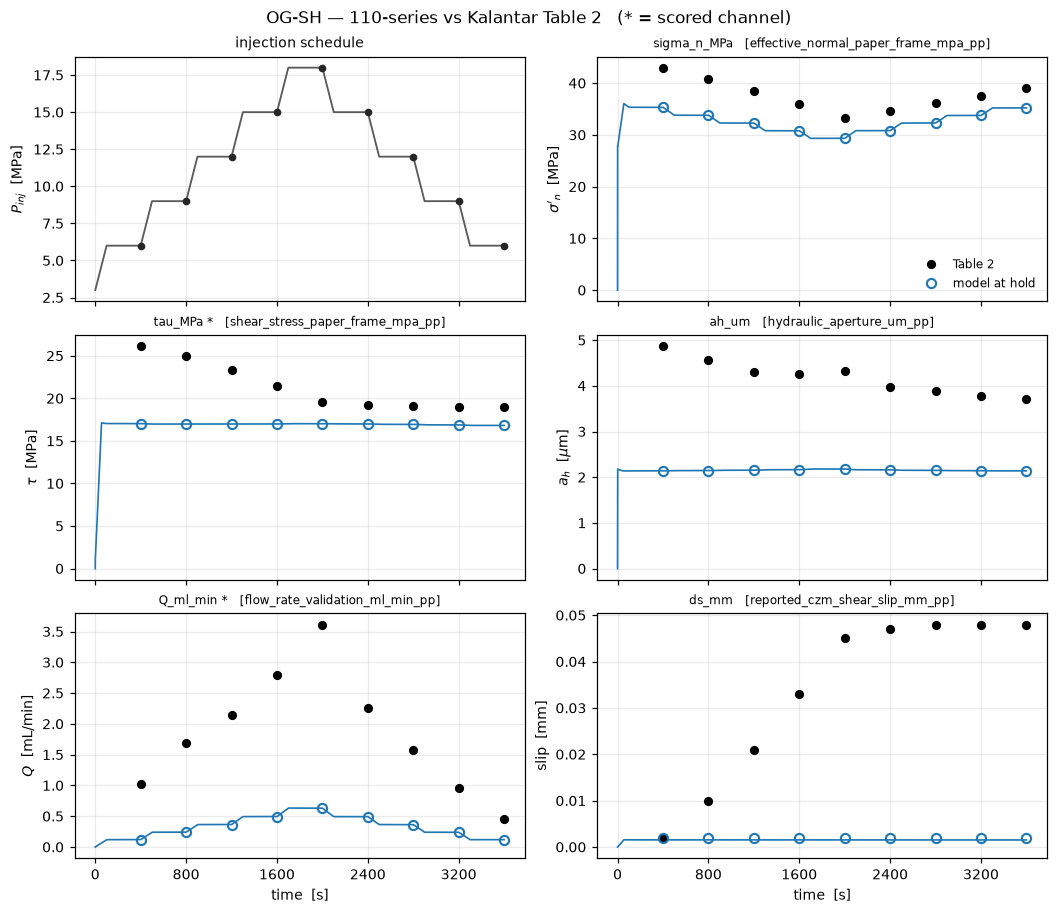

In [8]:
CHANNELS = [("sigma_n_MPa", "sn", r"$\sigma'_n$  [MPa]"),
            ("tau_MPa",     "tau", r"$\tau$  [MPa]"),
            ("ah_um",       "ah",  r"$a_h$  [$\mu$m]"),
            ("Q_ml_min",    "Q",   r"$Q$  [mL/min]"),
            ("ds_mm",       "ds",  r"slip  [mm]")]

def plot_channels(sample):
    cfg, tab = LOADED[sample], STAGE_TABLES[sample]
    df, res = cfg["df"], SCORES.get(sample)
    scored = set(res["scored"]) if res else set()
    fig, axes = plt.subplots(3, 2, figsize=(9.5, 8.2), sharex=True)
    x, y = KG.parse_schedule(cfg["deck"])

    ax = axes.flat[0]
    ax.plot(x, y, color="0.35", lw=1.2)
    ax.plot(tab["t_s"], tab["Pi"], "o", ms=4, color="0.15")
    ax.set_ylabel(r"$P_{inj}$  [MPa]"); ax.set_title("injection schedule", fontsize=9)

    for ax, (key, label, ylab) in zip(axes.flat[1:], CHANNELS):
        series, name = KG.first_column(df, KG.KAL_COLUMNS[key])
        if series is not None:
            ax.plot(df["time"], series, lw=1.1, color=COLOR[sample])
        ax.plot(tab["t_s"], tab[f"{label}_meas"], "o", ms=5, color="k",
                label="Table 2", zorder=5)
        ax.plot(tab["t_s"], tab[f"{label}_sim"], "o", ms=6, mfc="none",
                mec=COLOR[sample], mew=1.4, label="model at hold", zorder=6)
        star = " *" if key in scored else ""
        ax.set_ylabel(ylab)
        ax.set_title(f"{key}{star}" + (f"   [{name}]" if name else "   [not emitted]"),
                     fontsize=8)
        ax.xaxis.set_major_locator(MaxNLocator(5))
    axes.flat[1].legend(loc="best", fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("time  [s]")
    fig.suptitle(f"{sample} — 110-series vs Kalantar Table 2   "
                 f"(* = scored channel)", fontsize=11)
    return fig

CHANNEL_FIGS = {s: plot_channels(s) for s in LOADED}
plt.show()

## 9. Stress path and the failure envelope

The experiment walks *down and left* in (σ'ₙ, τ) as injection raises pore pressure: σ'ₙ
falls, and τ falls too once the joint slips. Plotting the model's path against the
measurement together with the deck's own Barton–Bandis envelope shows immediately
whether a miss is a **loading** problem (path in the wrong place) or a **strength**
problem (path right, envelope wrong).

The envelope drawn is the deck's peak criterion
`tau = sigma'_n tan[phi_r + JRC log10(JCS/sigma'_n)] + c`, read straight out of the deck.

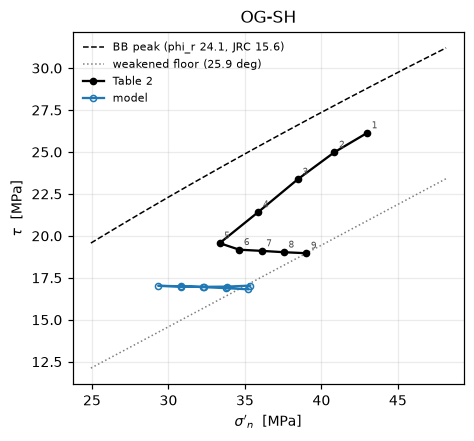

In [9]:
def deck_params(deck):
    t = deck.read_text()
    def grab(k, default=np.nan):
        m = re.search(rf"^\s+{k}\s*=\s*([0-9.eE+-]+)", t, re.M)
        return float(m.group(1)) if m else default
    return dict(jrc=grab("jrc"), jcs=grab("jcs"), phi_r=grab("residual_friction_angle_degrees"),
                cohesion=grab("cohesion", 0.0),
                phi_sw=grab("slip_weakening_residual_friction_angle_degrees"))

def bb_envelope(sn_mpa, p):
    sn = np.clip(sn_mpa, 1e-3, None)
    phi = p["phi_r"] + p["jrc"] * np.log10(p["jcs"] / 1e6 / sn)
    return sn * np.tan(np.radians(np.clip(phi, 0, 85))) + p["cohesion"] / 1e6

fig, axes = plt.subplots(1, max(1, len(LOADED)), figsize=(4.2 * max(1, len(LOADED)), 3.9),
                         squeeze=False)
for ax, s in zip(axes.flat, LOADED):
    tab, p = STAGE_TABLES[s], deck_params(LOADED[s]["deck"])
    lo = min(tab["sn_meas"].min(), np.nanmin(tab["sn_sim"])) * 0.85
    hi = max(tab["sn_meas"].max(), np.nanmax(tab["sn_sim"])) * 1.12
    grid = np.linspace(lo, hi, 200)
    ax.plot(grid, bb_envelope(grid, p), "k--", lw=1.0,
            label=f"BB peak (phi_r {p['phi_r']:.1f}, JRC {p['jrc']:.1f})")
    ax.plot(grid, grid * np.tan(np.radians(p["phi_sw"])), ":", color="0.5", lw=1.0,
            label=f"weakened floor ({p['phi_sw']:.1f} deg)")
    ax.plot(tab["sn_meas"], tab["tau_meas"], "-o", ms=4, color="k", label="Table 2")
    ax.plot(tab["sn_sim"],  tab["tau_sim"],  "-o", ms=4, mfc="none",
            color=COLOR[s], label="model")
    for _, r in tab.iterrows():
        ax.annotate(int(r["stage"]), (r["sn_meas"], r["tau_meas"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points", color="0.3")
    ax.set_xlabel(r"$\sigma'_n$  [MPa]"); ax.set_ylabel(r"$\tau$  [MPa]")
    ax.set_title(s); ax.legend(fontsize=7, loc="upper left")
plt.show()

## 10. Aperture response

`a_h` against σ'ₙ, with the pressurisation and depressurisation branches drawn
separately. The **loop** is the informative part:

* **OG-SC and OG-T** open as σ'ₙ falls and close again — mostly reversible, with a
  residual offset.
* **OG-SH loses aperture monotonically** even though σ'ₙ *also* falls. A reversible
  closure law predicts the opposite sign, so that loss has to be irreversible — this is
  the paper's gouge result (§4.2: 12× OG-T's gouge mass), and in the deck it is carried
  by `slip_damage_scale`, the one term in the aperture law that subtracts.

If the model's loop is the right shape but the wrong height, the anchor
(`initial_hydraulic_aperture` at `reference_effective_normal_stress`) is off. If it is
flat when the measurement loops, the closure law is inert at these stresses.

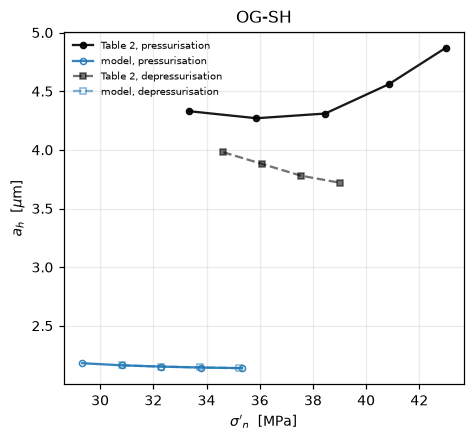

Measured a_h endpoints (stage 1 -> last):
  OG-SH   4.87 ->  3.72 um while sigma'_n went 42.99 -> 39.02 MPa
  OG-T    0.10 ->  0.00 um while sigma'_n went 63.86 -> 39.35 MPa
  OG-SC   1.03 ->  0.58 um while sigma'_n went 36.10 -> 33.87 MPa


In [10]:
fig, axes = plt.subplots(1, max(1, len(LOADED)), figsize=(4.2 * max(1, len(LOADED)), 3.9),
                         squeeze=False)
for ax, s in zip(axes.flat, LOADED):
    tab, ref = STAGE_TABLES[s], REF[s]
    br = ref["branch"].to_numpy()[:len(tab)]
    for mask, style, lab in [(br == "pressurization", "-o", "pressurisation"),
                             (br == "depressurization", "--s", "depressurisation")]:
        ax.plot(tab["sn_meas"][mask], tab["ah_meas"][mask], style, ms=4, color="k",
                label=f"Table 2, {lab}", alpha=0.9 if style == "-o" else 0.55)
        ax.plot(tab["sn_sim"][mask], tab["ah_sim"][mask], style, ms=4, mfc="none",
                color=COLOR[s], label=f"model, {lab}", alpha=0.9 if style == "-o" else 0.55)
    ax.set_xlabel(r"$\sigma'_n$  [MPa]"); ax.set_ylabel(r"$a_h$  [$\mu$m]")
    ax.set_title(s); ax.legend(fontsize=6.5)
plt.show()

print("Measured a_h endpoints (stage 1 -> last):")
for s in SPECIMENS:
    r = REF[s]
    print(f"  {s:6s} {r['ah_um'].iloc[0]:5.2f} -> {r['ah_um'].iloc[-1]:5.2f} um "
          f"while sigma'_n went {r['sigma_n_MPa'].iloc[0]:5.2f} -> "
          f"{r['sigma_n_MPa'].iloc[-1]:5.2f} MPa")

## 11. Error summary

One panel per scored channel, stage on the x-axis. Reading it:

* a **flat offset** = a level error — loading gate, or an anchor constant;
* a **trend across stages** = a slope error — the constitutive law's stress dependence;
* a **step at one stage** = an event landing at the wrong time.

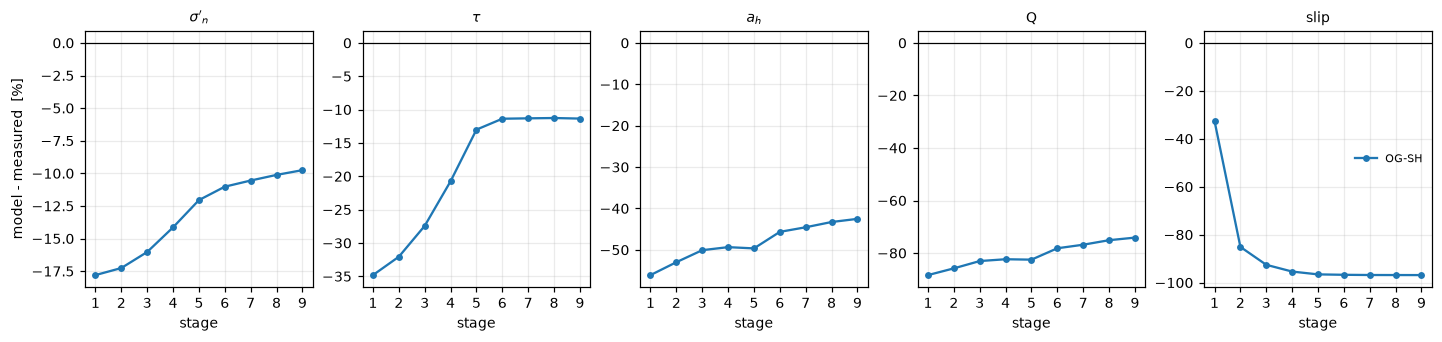

In [11]:
if STAGE_TABLES:
    labels = [("sn", r"$\sigma'_n$"), ("tau", r"$\tau$"), ("ah", r"$a_h$"),
              ("Q", "Q"), ("ds", "slip")]
    fig, axes = plt.subplots(1, len(labels), figsize=(2.6 * len(labels), 3.0), sharex=True)
    for ax, (lab, title) in zip(axes, labels):
        for s, tab in STAGE_TABLES.items():
            ax.plot(tab["stage"], tab[f"{lab}_err%"], "-o", ms=3.5,
                    color=COLOR[s], label=s)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(title, fontsize=9); ax.set_xlabel("stage")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].set_ylabel("model - measured  [%]")
    axes[-1].legend(fontsize=7)
    plt.show()

## 12. What to check before believing a result

1. **Completeness** (§4) — a truncated CSV scores the early stages and looks merely bad.
2. **The frame check** (§5) — if `ds_mm` misses while `tau_MPa` is fine, the problem is
   `axial_bc_penalty`, not the joint law.
3. **The loading gate** — if τ is uniformly low at stage 1, `axial_pres_final` has not
   converged; re-derive it from `u_cmd = sigma_1/penalty + C_ax*(sigma_1 - sigma_3)`
   rather than scaling by eye.
4. **Sign of the aperture drift on OG-SH** (§10) — this is the specimen's whole result.
5. **Whether OG-SC bursts at all.** Stick-slip needs `D_c < d(tau)/k_eff`; the deck
   header prints both numbers.

Related documents:

* `doc/reading_kalantar2025_self_propping_granodiorite.md` — full reading notes and audit
* `doc/KALANTAR2025_VALIDATION_PLAN.md` — the plan and its gates
* `scripts/build_110_kalantar_decks.py` — where every deck constant comes from
* `scripts/kalantar_gate.py` — the scoring machinery imported above